In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import copy

In [42]:
df = pd.read_csv("C:/Users/shami/Downloads/archive (1)/student_exam_performance_dataset.csv")
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [43]:
df['pass_fail'] = df['pass_fail'].map({
    'Pass' : 1,
    'Fail' : 0
})
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,0,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,1,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,0,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,0,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,1,C


In [44]:
Y = df['pass_fail'].to_numpy().reshape(df.shape[0],1)

In [45]:
df = df.drop(['student_id','final_exam_score','grade_category','pass_fail'],axis = 1)
df = pd.get_dummies(df,columns = ['gender','parental_education','family_income','internet_access','study_environment','tutoring'])
df.head()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,...,family_income_High,family_income_Low,family_income_Medium,internet_access_No,internet_access_Yes,study_environment_Moderate,study_environment_Noisy,study_environment_Quiet,tutoring_No,tutoring_Yes
0,17,2.98,96.5,6.05,0.1,80.5,68.7,1,42.8,62.4,...,False,False,True,False,True,False,False,True,False,True
1,18,4.45,95.7,6.96,2.9,70.9,92.6,0,77.9,73.5,...,False,True,False,False,True,False,False,True,False,True
2,17,3.75,76.0,7.02,2.4,77.6,45.8,4,53.5,38.3,...,False,False,True,True,False,False,False,True,False,True
3,18,2.03,72.6,6.23,3.5,63.5,72.9,4,28.3,23.5,...,False,False,True,False,True,False,False,True,True,False
4,18,5.14,87.3,8.54,2.1,71.8,55.7,0,74.7,54.9,...,False,False,True,False,True,False,False,True,True,False


In [46]:
X = df.to_numpy()
print(X.shape)
print(Y.shape)

(10000, 29)
(10000, 1)


In [47]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 0
)
print(X_train.shape)
print(Y_train.shape)

(8000, 29)
(8000, 1)


In [48]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
X_train,X_test,Y_train,Y_test = X_train.T,X_test.T,Y_train.T,Y_test.T

In [50]:
def sigmoid(Z):
    A = 1/(1 + np.exp(-Z))
    cache = Z
    return A,cache

In [51]:
def relu(Z):
    A = np.maximum(0,Z)
    cache = Z
    return A,cache

In [52]:
def sigmoid_backward(dA,activation_cache):
    A = 1/(1 + np.exp(-activation_cache))
    dZ = dA * A * (1 - A)
    return dZ

In [53]:
def relu_backward(dA, activation_cache):
    Z = activation_cache
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0    
    return dZ

In [54]:
layers_dims = (X_train.shape[0],20,10,1)

In [55]:
def initialize_parameters(layers_dims):
    L = len(layers_dims)
    params = {}
    for l in range(1,L):
        params['W' + str(l)] = np.random.randn(layers_dims[l],layers_dims[l - 1]) * 0.01
        params['b' + str(l)] = np.zeros((layers_dims[l],1))
    return params

In [56]:
def linear_forward(A_prev,W,b):
    Z = np.dot(W,A_prev) + b
    cache = (A_prev,W,b)
    return Z,cache

In [57]:
def linear_activation_forward(A_prev,W,b,activation):
    if activation == "sigmoid":
        Z,linear_cache = linear_forward(A_prev,W,b)
        A,activation_cache = sigmoid(Z)
    elif activation == "relu":
        Z,linear_cache = linear_forward(A_prev,W,b)
        A,activation_cache = relu(Z)
    cache = (linear_cache,activation_cache)
    return A,cache

In [58]:
def model_forward(X,parameters):
    caches = []
    A = X
    L = len(parameters) // 2
    for l in range(1,L):
        A_prev = A
        A,cache = linear_activation_forward(A_prev,parameters['W' + str(l)],parameters['b' + str(l)],"relu")
        caches.append(cache)
    AL,cache = linear_activation_forward(A,parameters['W' + str(L)],parameters['b' + str(L)],"sigmoid")
    caches.append(cache)
    return AL,caches

In [59]:
def compute_cost(AL,Y):
    m = Y.shape[1]
    logprobs = np.multiply(Y,np.log(AL)) + np.multiply(1 - Y,np.log(1 - AL))
    cost = -1/m * np.sum(logprobs)
    cost = np.squeeze(cost)
    return cost

In [60]:
def linear_backward(dZ,cache):
    A_prev,W,b = cache
    m = A_prev.shape[1]
    dW = 1/m * np.dot(dZ,A_prev.T)
    db = 1/m * np.sum(dZ,axis = 1,keepdims = True)
    dA_prev = np.dot(W.T,dZ)
    return dA_prev,dW,db

In [61]:
def linear_activation_backward(dA,cache,activation):
    linear_cache,activation_cache = cache
    if activation == "relu":
        dZ = relu_backward(dA,activation_cache)
        dA_prev,dW,db = linear_backward(dZ,linear_cache)
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA,activation_cache)
        dA_prev,dW,db = linear_backward(dZ,linear_cache)
    return dA_prev,dW,db

In [62]:
def model_backward(AL,Y,caches):
    grads = {}
    L = len(caches)
    m = AL.shape[1]
    Y = Y.reshape(AL.shape)
    dAL = -np.divide(Y,AL) + np.divide(1 - Y,1 - AL)
    current_cache = caches[L - 1]
    dA_prev_temp,dW_temp,db_temp = linear_activation_backward(dAL,current_cache,"sigmoid")
    grads['dA' + str(L - 1)] = dA_prev_temp
    grads['dW' + str(L)] = dW_temp
    grads['db' + str(L)] = db_temp
    for l in reversed(range(L - 1)):
        current_cache = caches[l]
        dA_prev_temp,dW_temp,db_temp = linear_activation_backward(grads['dA' + str(l + 1)],current_cache,"relu")
        grads['dA' + str(l)] = dA_prev_temp
        grads['dW' + str(l + 1)] = dW_temp
        grads['db' + str(l + 1)] = db_temp
    return grads

In [63]:
def update_parameters(params,grads,learning_rate):
    L = len(params) // 2
    parameters = copy.deepcopy(params)
    for l in range(L):
        parameters['W' + str(l + 1)] -= learning_rate * grads['dW' + str(l + 1)]
        parameters['b' + str(l + 1)] -= learning_rate * grads['db' + str(l + 1)]
    return parameters

In [64]:
parameters = initialize_parameters(layers_dims)
costs = []

In [65]:
for i in range(5000):
    AL,caches = model_forward(X_train,parameters)
    cost = compute_cost(AL,Y_train)
    costs.append(cost)
    grads = model_backward(AL,Y_train,caches)
    parameters = update_parameters(parameters,grads,0.05)

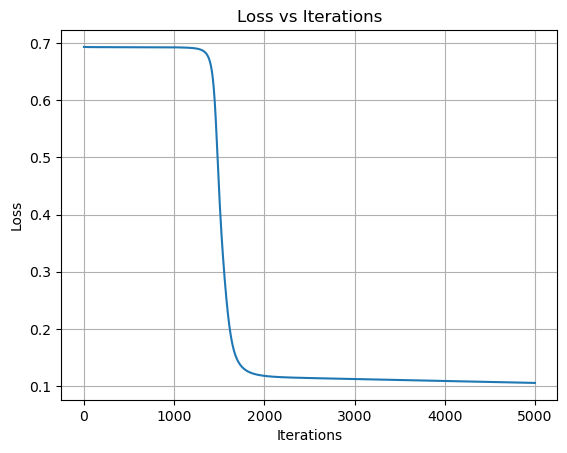

In [66]:
plt.plot(costs)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")

plt.grid(True)

plt.show()

In [67]:
predictions = np.round(AL)

In [68]:
train_accuracy = np.mean(predictions == Y_train)
print(train_accuracy)

0.954125


In [69]:
AL_test, _ = model_forward(X_test, parameters)
predictions = (AL_test > 0.5).astype(int)

accuracy = np.mean(predictions == Y_test)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9495


In [70]:
print("Final cost:", cost)

AL_test, _ = model_forward(X_test, parameters)

print("AL min:", np.min(AL_test))
print("AL max:", np.max(AL_test))
print("AL mean:", np.mean(AL_test))

predictions = (AL_test > 0.5).astype(int)

print("Prediction counts:")
print(np.unique(predictions, return_counts=True))

print("Actual counts:")
print(np.unique(Y_test, return_counts=True))

Final cost: 0.1053739877126456
AL min: 5.996823223121948e-10
AL max: 0.9999999999914457
AL mean: 0.48869742556960466
Prediction counts:
(array([0, 1]), array([1034,  966]))
Actual counts:
(array([0, 1]), array([1031,  969]))
